datetime64[s]
['CO_ppb', 'NO_ppb', 'SO2_ppb', 'SA_moleccm3', 'Dimers_moleccm3']


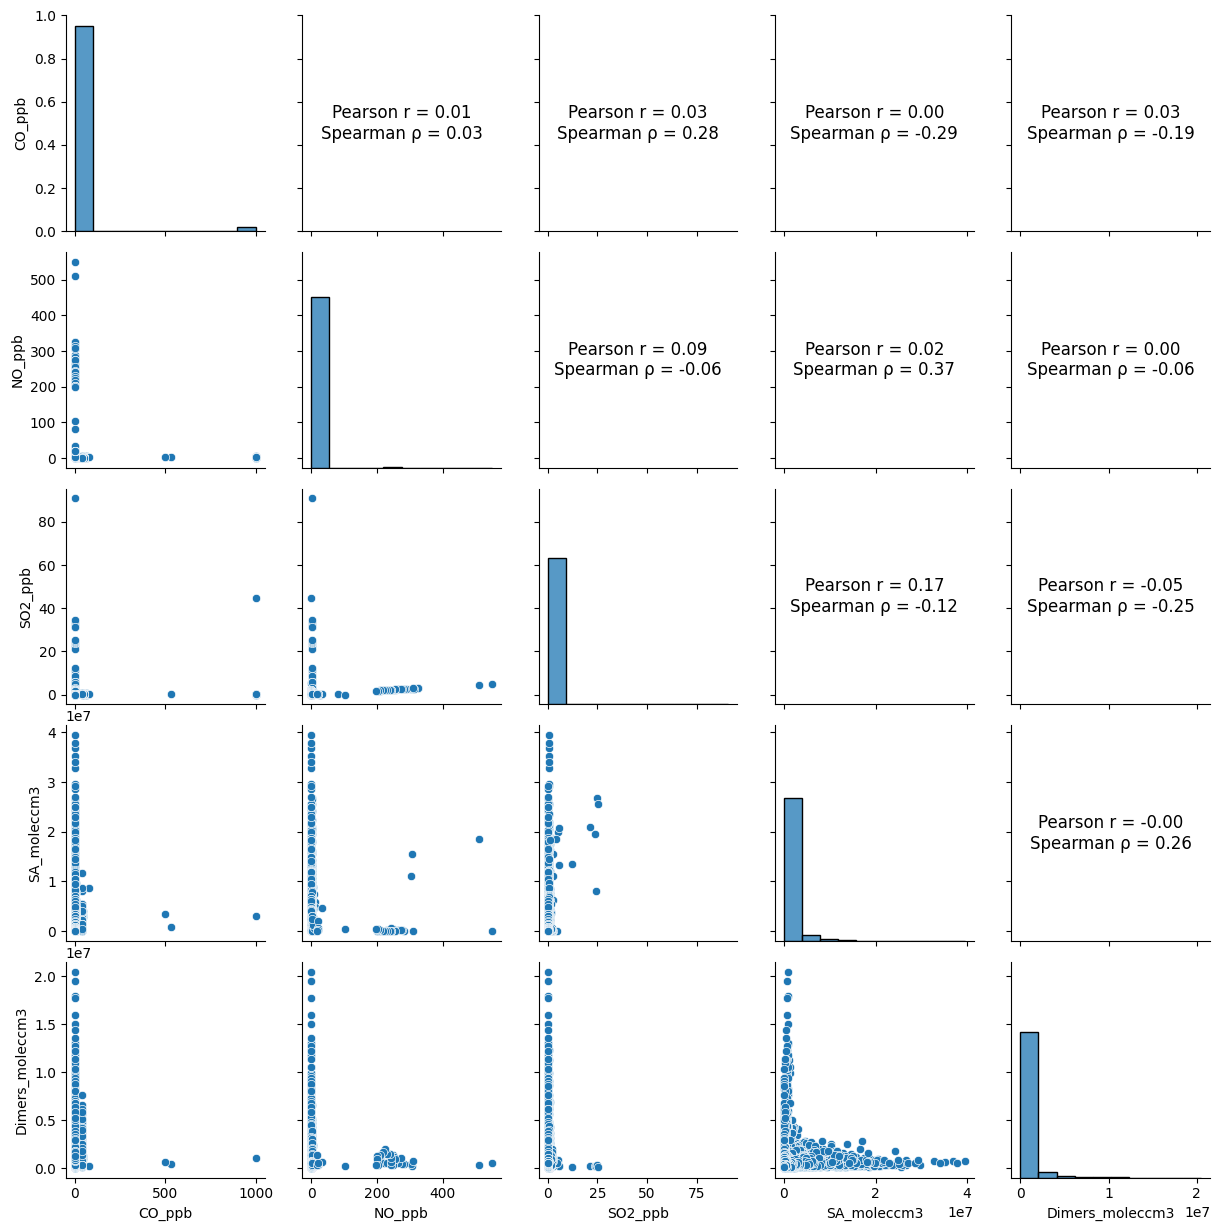

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path


COMBINED_PATH = "../local/Tvarminne/combined/combined.csv"

df = pd.read_csv(COMBINED_PATH, engine='pyarrow', index_col="Time")

GROUP_MAP_KEY_ORIGINAL = "original"
GROUP_MAP_KEY_NEW = "new"

GROUP_MAP = {
    "Dominik" : ["CO_ppb", "NO_ppb", "SO2_ppb","SA_moleccm3","Dimers_moleccm3"]
}

print(df.index.dtype)

df_subset_columns = GROUP_MAP.get("Dominik", [])

print(df_subset_columns)

df_subset = df[GROUP_MAP["Dominik"]]

def corrfunc(x, y, **kws):
    r_pearson = x.corr(y, method="pearson"),
    r_spearman = x.corr(y, method="spearman")

    ax = plt.gca()
    ax.annotate(f"Pearson r = {r_pearson:.2f}\nSpearman ρ = {r_spearman:.2f}",
                xy=(.5, .5),
                xycoords=ax.transAxes,
                ha='center',
                va='center',
                fontsize=12)

g = sns.PairGrid(df_subset)
g.map_upper(corrfunc)          # correlation in upper triangle
g.map_lower(sns.scatterplot)   # scatterplots
g.map_diag(sns.histplot, bins=10)       # distributions

plt.show()



# g = sns.pairplot(df_subset, diag_kind="hist")

# for ax in g.axes.flatten():
#     if ax is not None:
#         ax.autoscale()

# plt.show()

# plt.show()

